In [1]:
Lab: การสร้างโมเดลจำแนกมะเร็งเต้านมด้วย Logistic Regression
เป้าหมายของ Lab: สร้างโมเดล Machine Learning ที่สามารถทำนายได้ว่าก้อนเนื้อที่ตรวจพบเป็นเนื้อร้าย (Malignant) หรือเนื้อดี (Benign) โดยอาศัยข้อมูลคุณลักษณะต่างๆ ของเซลล์

ชุดข้อมูล: Breast Cancer Wisconsin (Diagnostic) Dataset จาก Scikit-learn

SyntaxError: invalid syntax (3066768145.py, line 1)

In [ ]:
ส่วนที่ 1: การตั้งค่าและนำเข้าข้อมูล (Setup & Data Loading)
(Copy Code ส่วนนี้ไปวางใน Cell ที่ 1 ของ Colab)

คำอธิบาย: ขั้นตอนนี้เป็นการเตรียมความพร้อม โดยการนำเข้าไลบรารีที่จำเป็นสำหรับการทำงานทั้งหมด

- pandas และ numpy สำหรับจัดการข้อมูล
- matplotlib และ seaborn สำหรับการวาดกราฟเพื่อสำรวจข้อมูล
- sklearn สำหรับเครื่องมือ Machine Learning ทั้งหมด ตั้งแต่การโหลดข้อมูล, แบ่งข้อมูล, สร้างโมเดล, และวัดผล

In [2]:
# === Cell 1: Import Libraries ===

# 1. ไลบรารีสำหรับจัดการข้อมูล
import pandas as pd
import numpy as np

# 2. ไลบรารีสำหรับสร้างกราฟ
import matplotlib.pyplot as plt
import seaborn as sns

# 3. ไลบรารีสำหรับ Machine Learning จาก Scikit-learn
# 3.1 สำหรับโหลดข้อมูลตัวอย่าง
from sklearn.datasets import load_breast_cancer
# 3.2 สำหรับแบ่งข้อมูล
from sklearn.model_selection import train_test_split
# 3.3 สำหรับทำ Feature Scaling
from sklearn.preprocessing import StandardScaler
# 3.4 สำหรับสร้างโมเดล Logistic Regression
from sklearn.linear_model import LogisticRegression
# 3.5 สำหรับวัดผลโมเดล
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
ส่วนที่ 2: การโหลดและสำรวจข้อมูลเบื้องต้น (Exploratory Data Analysis - EDA)
(Copy Code ส่วนนี้ไปวางใน Cell ที่ 2 ของ Colab)

คำอธิบาย: เราจะโหลดชุดข้อมูลจาก sklearn และแปลงให้อยู่ในรูปแบบของ Pandas DataFrame เพื่อให้ง่ายต่อการวิเคราะห์ จากนั้นจะทำการสำรวจข้อมูลเบื้องต้นเพื่อทำความเข้าใจลักษณะของข้อมูล

load_breast_cancer(): โหลดชุดข้อมูลซึ่งมาพร้อมกับข้อมูล (data), เป้าหมาย (target), และชื่อคอลัมน์ (feature_names)
.head(): แสดงข้อมูล 5 แถวแรก
.info(): สรุปข้อมูลโดยรวม เช่น จำนวนข้อมูล, ประเภทข้อมูลในแต่ละคอลัมน์
.isnull().sum(): ตรวจสอบว่ามีข้อมูลที่หายไป (Missing Values) หรือไม่
.describe(): ดูค่าสถิติเบื้องต้นของแต่ละคอลัมน์ เช่น ค่าเฉลี่ย, ค่าสูงสุด, ค่าต่ำสุด
sns.countplot(): วาดกราฟนับจำนวนของแต่ละคลาสในตัวแปรเป้าหมาย เพื่อดูว่าข้อมูลมีความสมดุลหรือไม่

--- 5 แถวแรกของข้อมูล ---
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wo

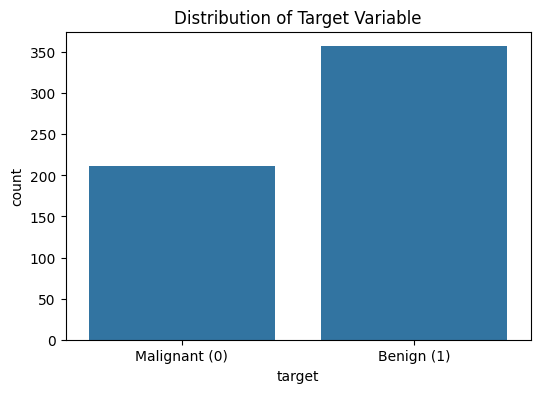

In [3]:
# === Cell 2: Load and Explore Dataset ===

# 1. โหลดข้อมูลจาก Scikit-learn
cancer_data = load_breast_cancer()

# 2. สร้าง Pandas DataFrame เพื่อให้ง่ายต่อการใช้งาน
# cancer_data.data คือข้อมูลคุณลักษณะ (features)
# cancer_data.feature_names คือชื่อคอลัมน์ของ features
df = pd.DataFrame(data=cancer_data.data, columns=cancer_data.feature_names)

# เพิ่มคอลัมน์เป้าหมาย (target) เข้าไปใน DataFrame
# 0 = Malignant (เนื้อร้าย), 1 = Benign (เนื้อดี)
df['target'] = cancer_data.target

# 3. สำรวจข้อมูลเบื้องต้น
print("--- 5 แถวแรกของข้อมูล ---")
print(df.head())
print("\n" + "="*50 + "\n")

print("--- ข้อมูลทั่วไปของ DataFrame ---")
df.info()
print("\n" + "="*50 + "\n")

print("--- ตรวจสอบข้อมูลที่หายไป (Missing Values) ---")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

print("--- ค่าสถิติเบื้องต้น ---")
print(df.describe())
print("\n" + "="*50 + "\n")

# 4. แสดงการกระจายของข้อมูลเป้าหมาย
print("--- การกระจายของ Target (0:Malignant, 1:Benign) ---")
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Variable')
plt.xticks([0, 1], ['Malignant (0)', 'Benign (1)'])
plt.show()

In [ ]:
ส่วนที่ 3: การเตรียมข้อมูล (Data Preparation)
(Copy Code ส่วนนี้ไปวางใน Cell ที่ 3 ของ Colab)

คำอธิบาย: ขั้นตอนนี้ เราจะแยกข้อมูลออกเป็น 2 ส่วน คือ

1 Features (X): ข้อมูลคุณลักษณะทั้งหมดที่เราจะใช้ในการทำนาย (ทุกคอลัมน์ยกเว้น target)
2. Target (y): คอลัมน์เป้าหมายที่เราต้องการทำนาย (target)

จากนั้น เราจะแบ่งข้อมูลทั้งหมดออกเป็นชุดสำหรับ "ฝึก" (Training set) และชุดสำหรับ "ทดสอบ" (Testing set) เพื่อให้เราสามารถวัดผลโมเดลกับข้อมูลที่โมเดลไม่เคยเห็นมาก่อนได้

In [4]:
# === Cell 3: Prepare Data and Split into Train/Test Sets ===

# 1. กำหนด Features (X) และ Target (y)
X = df.drop('target', axis=1) # เอาทุกคอลัมน์ยกเว้น 'target'
y = df['target'] # เอาเฉพาะคอลัมน์ 'target'

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# 2. แบ่งข้อมูลเป็นชุด Training (80%) และ Testing (20%)
# random_state=42 เพื่อให้ผลการแบ่งข้อมูลเหมือนเดิมทุกครั้งที่รัน
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- ขนาดของข้อมูลหลังการแบ่ง ---")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Shape of X: (569, 30)
Shape of y: (569,)

--- ขนาดของข้อมูลหลังการแบ่ง ---
X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


In [ ]:
ส่วนที่ 4: การทำ Feature Scaling
(Copy Code ส่วนนี้ไปวางใน Cell ที่ 4 ของ Colab)

คำอธิบาย: โมเดล Logistic Regression (และโมเดลอื่นๆ) จะทำงานได้ดีขึ้นเมื่อข้อมูลแต่ละ feature มีสเกลใกล้เคียงกัน เราจึงต้องทำ Feature Scaling เพื่อปรับสเกลของข้อมูล

- ราจะใช้ StandardScaler ซึ่งจะปรับข้อมูลให้มีค่าเฉลี่ยเป็น 0 และส่วนเบี่ยงเบนมาตรฐานเป็น 1
- สำคัญ: เราจะ fit_transform (เรียนรู้และแปลง) กับข้อมูล X_train เท่านั้น และใช้ scaler ที่เรียนรู้แล้วไป transform (แปลง) กับข้อมูล X_test 
เพื่อป้องกันไม่ให้ข้อมูลจากชุดทดสอบรั่วไหลไปในขั้นตอนการฝึก

In [5]:
# === Cell 4: Feature Scaling ===

# 1. สร้าง object ของ StandardScaler
scaler = StandardScaler()

# 2. ทำการ fit_transform กับข้อมูล X_train (เรียนรู้และแปลงค่า)
X_train_scaled = scaler.fit_transform(X_train)

# 3. ทำการ transform กับข้อมูล X_test (ใช้ค่าที่เรียนรู้จาก train มาแปลง)
X_test_scaled = scaler.transform(X_test)

# แสดงตัวอย่างข้อมูลที่ถูก scale แล้ว
print("--- ตัวอย่างข้อมูล X_train ก่อนทำ Scaling ---")
print(X_train.head(1))
print("\n--- ตัวอย่างข้อมูล X_train หลังทำ Scaling ---")
print(X_train_scaled[0])

--- ตัวอย่างข้อมูล X_train ก่อนทำ Scaling ---
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
546        10.32         16.35           65.31      324.9          0.09434   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
546           0.04994         0.01012             0.005495         0.1885   

     mean fractal dimension  ...  worst radius  worst texture  \
546                 0.06201  ...         11.25          21.77   

     worst perimeter  worst area  worst smoothness  worst compactness  \
546            71.12       384.9            0.1285            0.08842   

     worst concavity  worst concave points  worst symmetry  \
546          0.04384               0.02381          0.2681   

     worst fractal dimension  
546                  0.07399  

[1 rows x 30 columns]

--- ตัวอย่างข้อมูล X_train หลังทำ Scaling ---
[-1.07200079e+00 -6.58424598e-01 -1.08808010e+00 -9.39273639e-01
 -1.35939882e-01 -1.00871795e+00 -9.683586

In [ ]:
ส่วนที่ 5: การสร้างและฝึกโมเดล (Model Training)
(Copy Code ส่วนนี้ไปวางใน Cell ที่ 5 ของ Colab)

คำอธิบาย: ถึงขั้นตอนการสร้างโมเดลแล้ว!

เราสร้าง object ของ LogisticRegression
ใช้คำสั่ง .fit() เพื่อฝึกโมเดล โดยใช้ข้อมูล X_train_scaled และ y_train

In [6]:
# === Cell 5: Train the Logistic Regression Model ===

# 1. สร้าง instance ของโมเดล
model = LogisticRegression(random_state=42)

# 2. ฝึกโมเดลด้วยข้อมูล training ที่ scale แล้ว
print("Training the model...")
model.fit(X_train_scaled, y_train)
print("Model training completed!")

Training the model...
Model training completed!


In [ ]:
ส่วนที่ 6: การทำนายและวัดผลโมเดล (Prediction & Evaluation)
(Copy Code ส่วนนี้ไปวางใน Cell ที่ 6 ของ Colab)

คำอธิบาย: หลังจากฝึกโมเดลเสร็จ เราจะนำโมเดลมาทดสอบประสิทธิภาพกับข้อมูล X_test_scaled ที่มันไม่เคยเห็นมาก่อน

1. ใช้ .predict() เพื่อทำนายผล
2. Accuracy: วัดความแม่นยำโดยรวม (ทายถูกกี่เปอร์เซ็นต์)
3. Confusion Matrix: ตารางที่แสดงผลการทำนายเทียบกับค่าจริง ช่วยให้เห็นว่าโมเดลทายผิดพลาดในลักษณะใด (เช่น ทายว่าเนื้อดีแต่จริงๆ เป็นเนื้อร้าย)
    - TN (True Negative): ทายถูกว่าเป็น Benign (1)
    - FP (False Positive): ทายผิดว่าเป็น Malignant (0) แต่จริงๆ เป็น Benign (1) -> False Alarm
    - FN (False Negative): ทายผิดว่าเป็น Benign (1) แต่จริงๆ เป็น Malignant (0) -> Missed Detection (อันตรายที่สุดในเคสนี้)
    - TP (True Positive): ทายถูกว่าเป็น Malignant (0)
4. Classification Report: สรุปค่าชี้วัดที่สำคัญอื่นๆ เช่น Precision, Recall, F1-score ซึ่งให้มุมมองที่ลึกกว่า Accuracy

Accuracy: 98.25%


--- Confusion Matrix ---
[[41  1]
 [ 1 71]]


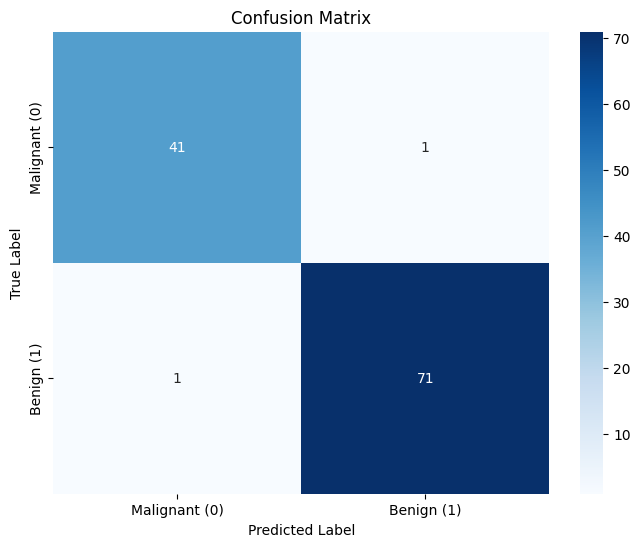



--- Classification Report ---
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



In [7]:
# === Cell 6: Make Predictions and Evaluate the Model ===

# 1. ทำนายผลจากข้อมูล test set
y_pred = model.predict(X_test_scaled)

# 2. วัดผลด้วย Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\n" + "="*50 + "\n")

# 3. สร้างและแสดง Confusion Matrix
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# วาดกราฟ Confusion Matrix เพื่อให้ดูง่ายขึ้น
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Malignant (0)', 'Benign (1)'], 
            yticklabels=['Malignant (0)', 'Benign (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
print("\n" + "="*50 + "\n")

# 4. แสดง Classification Report
print("--- Classification Report ---")
report = classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)'])
print(report)

In [ ]:
Lab (เพิ่มเติม): สร้างโมเดลจำแนกมะเร็งเต้านมด้วย Logistic Regression และ Hyperparameter Tuning
เป้าหมายของ Lab (ปรับปรุง):

1. สร้างโมเดล Logistic Regression เพื่อจำแนกประเภทก้อนเนื้อ
2. เรียนรู้วิธีการค้นหา Hyperparameter ที่ดีที่สุด (C และ solver) โดยใช้ GridSearchCV
3. เปรียบเทียบประสิทธิภาพระหว่างโมเดลที่ใช้ค่า default กับโมเดลที่ผ่านการทำ Hyperparameter Tuning

Cell 1-4 จะเหมือนกับ Lab เดิม: Import, Load Data, Prepare Data, Feature Scaling

In [ ]:
ส่วนที่ 5 (ใหม่): สร้างและฝึกโมเดลพื้นฐาน (Baseline Model)

คำอธิบาย: ก่อนที่เราจะไปทำ Hyperparameter Tuning เราควรสร้าง "โมเดลพื้นฐาน" ขึ้นมาก่อน โดยใช้ค่า Hyperparameter ที่เป็นค่าเริ่มต้น (default) ของ Scikit-learn 
เพื่อใช้เป็นเกณฑ์เปรียบเทียบว่าโมเดลที่เราปรับจูนแล้วดีขึ้นจริงหรือไม่

In [8]:
# 1. สร้าง instance ของโมเดลด้วยค่า default
baseline_model = LogisticRegression(random_state=42)

# 2. ฝึกโมเดลด้วยข้อมูล training ที่ scale แล้ว
print("Training the baseline model...")
baseline_model.fit(X_train_scaled, y_train)
print("Baseline model training completed!")

# 3. ประเมินผลโมเดลพื้นฐาน
print("\n--- Baseline Model Evaluation ---")
y_pred_baseline = baseline_model.predict(X_test_scaled)
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Model Accuracy: {accuracy_baseline * 100:.2f}%")
print("\nClassification Report for Baseline Model:")
print(classification_report(y_test, y_pred_baseline, target_names=['Malignant (0)', 'Benign (1)']))

Training the baseline model...
Baseline model training completed!

--- Baseline Model Evaluation ---
Baseline Model Accuracy: 98.25%

Classification Report for Baseline Model:
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



In [ ]:
ส่วนที่ 6 (ใหม่): การทำ Hyperparameter Tuning ด้วย GridSearchCV
(Copy Code ส่วนนี้ไปวางใน Cell ที่ 6 ของ Colab)

คำอธิบาย: นี่คือหัวใจของส่วนที่เพิ่มเข้ามา เราจะใช้ GridSearchCV เพื่อค้นหาชุดค่า Hyperparameter ที่ให้ประสิทธิภาพดีที่สุดโดยอัตโนมัติ

- Hyperparameters ที่จะปรับจูน:
    - C: คือค่า Inverse of regularization strength (ค่ายิ่งน้อย หมายถึง regularization ยิ่งแรงขึ้น เพื่อป้องกัน Overfitting)
    - solver: คือ Algorithm ที่ใช้ในการแก้ปัญหา Optimization
- Parameter Grid (param_grid): เราจะสร้าง Dictionary ที่ระบุค่าต่างๆ ของ Hyperparameter ที่เราต้องการให้ GridSearchCV ลองทั้งหมด
- Cross-Validation (cv=5): GridSearchCV จะแบ่งข้อมูล Training set ออกเป็น 5 ส่วน (5-fold cross-validation) แล้ววนสอนและวัดผล 5 รอบ 
เพื่อให้แน่ใจว่าประสิทธิภาพของแต่ละชุด Hyperparameter นั้นเชื่อถือได้และไม่ขึ้นอยู่กับการแบ่งข้อมูลแบบสุ่มเพียงครั้งเดียว
- GridSearchCV Object: สร้าง object ขึ้นมาโดยระบุโมเดล, param_grid, และจำนวน cv
- .fit(): คำสั่งนี้จะเริ่มกระบวนการค้นหาทั้งหมด ซึ่งอาจใช้เวลานานกว่าการ fit ปกติ เพราะต้องฝึกโมเดลหลายรอบ

In [9]:
# === Cell 6: Hyperparameter Tuning with GridSearchCV ===

from sklearn.model_selection import GridSearchCV

# 1. กำหนด Hyperparameter ที่จะทดลอง (Parameter Grid)
# C: ค่า Regularization strength (ค่าน้อย -> Regularization แข็งแกร่ง)
# solver: อัลกอริทึมที่ใช้ในการ optimize
# penalty: ประเภทของ Regularization (l1 หรือ l2)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'], # 'saga' รองรับทั้ง l1 และ l2
    'penalty': ['l1', 'l2', 'elasticnet']
}

# 2. สร้าง instance ของ GridSearchCV
# estimator: โมเดลที่เราต้องการจะจูน
# param_grid: ค่าพารามิเตอร์ที่ต้องการทดลอง
# cv=5: ใช้ 5-fold cross-validation
# scoring='accuracy': เกณฑ์ที่ใช้วัดผลเพื่อหาโมเดลที่ดีที่สุด
# n_jobs=-1: ใช้ CPU ทุก core เพื่อให้ทำงานเร็วขึ้น
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000), # เพิ่ม max_iter ป้องกัน warning
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1 # แสดง log การทำงาน
)

# 3. เริ่มกระบวนการค้นหา Hyperparameter ที่ดีที่สุดบนข้อมูล train
print("Starting GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)
print("GridSearchCV completed!")

# 4. แสดงผล Hyperparameter ที่ดีที่สุดที่ค้นพบ
print("\n--- Best Hyperparameters Found ---")
print(grid_search.best_params_)

# 5. แสดง score ที่ดีที่สุดที่ได้จาก Cross-validation
print(f"\nBest Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

Starting GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV completed!

--- Best Hyperparameters Found ---
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross-Validation Accuracy: 98.02%


/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
300 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/li

In [ ]:
ส่วนที่ 7 (ใหม่): การประเมินผลโมเดลที่ดีที่สุด (Best Model Evaluation)
(Copy Code ส่วนนี้ไปวางใน Cell ที่ 7 ของ Colab)

คำอธิบาย: GridSearchCV หลังจากทำงานเสร็จ จะเก็บ "โมเดลที่ดีที่สุด" (ที่ถูกฝึกด้วยข้อมูล train ทั้งหมด โดยใช้ hyperparameter ที่ดีที่สุดที่หาเจอ) 
ไว้ใน attribute ที่ชื่อว่า best_estimator_

เราจะนำโมเดลที่ดีที่สุดนี้มาประเมินผลกับ Test set ซึ่งเป็นข้อมูลที่โมเดลไม่เคยเห็นมาก่อนในทุกขั้นตอน เพื่อวัดประสิทธิภาพที่แท้จริงของมัน และเปรียบเทียบกับ Baseline Model


--- Best Model Evaluation on Test Set ---
Tuned Model Accuracy: 97.37%
Baseline Model Accuracy: 98.25%


--- Confusion Matrix for Tuned Model ---


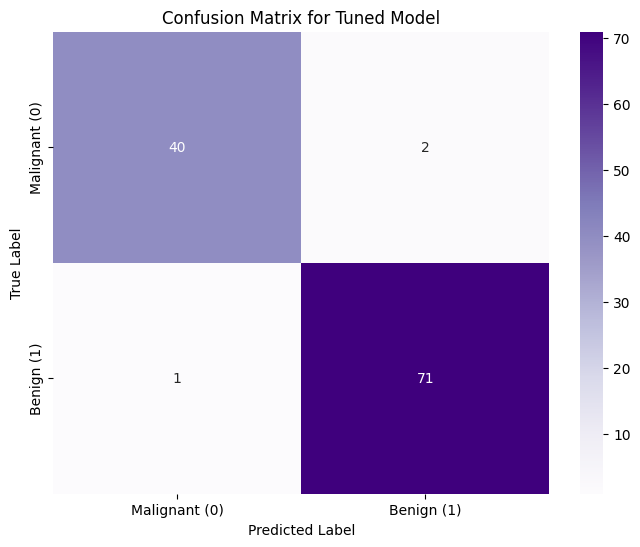



--- Classification Report for Tuned Model ---
               precision    recall  f1-score   support

Malignant (0)       0.98      0.95      0.96        42
   Benign (1)       0.97      0.99      0.98        72

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



In [10]:
# === Cell 7: Evaluate the Best Model Found by GridSearchCV ===

# 1. ดึงโมเดลที่ดีที่สุดออกมา
best_model = grid_search.best_estimator_

# 2. ทำนายผลจากข้อมูล test set ด้วยโมเดลที่ดีที่สุด
y_pred_best = best_model.predict(X_test_scaled)

# 3. ประเมินผลโมเดลที่ดีที่สุด
print("\n--- Best Model Evaluation on Test Set ---")
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Tuned Model Accuracy: {accuracy_best * 100:.2f}%")
print(f"Baseline Model Accuracy: {accuracy_baseline * 100:.2f}%") # เทียบกับ baseline
print("\n" + "="*50 + "\n")


# 4. แสดง Confusion Matrix ของโมเดลที่ดีที่สุด
print("--- Confusion Matrix for Tuned Model ---")
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Malignant (0)', 'Benign (1)'], 
            yticklabels=['Malignant (0)', 'Benign (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned Model')
plt.show()
print("\n" + "="*50 + "\n")


# 5. แสดง Classification Report ของโมเดลที่ดีที่สุด
print("--- Classification Report for Tuned Model ---")
print(classification_report(y_test, y_pred_best, target_names=['Malignant (0)', 'Benign (1)']))

In [ ]:
จุดสังเกตและข้อสรุปจาก Lab: นิสิตจะได้เห็นว่าโมเดลที่ผ่านการทำ Hyperparameter Tuning อาจจะมี Accuracy ที่สูงขึ้น (หรือเท่าเดิมในบางกรณี) แต่โดยทั่วไปแล้ว ค่า Precision และ Recall มักจะมีความสมดุลที่ดีขึ้น และโมเดลมีความน่าเชื่อถือมากกว่า 
เพราะผ่านการตรวจสอบด้วย Cross-Validation มาแล้ว

In [ ]:
การบ้านสำหรับนิสิต: สร้างโมเดลทำนายโรคหัวใจ
โจทย์: ให้นิสิตนำความรู้ที่ได้จาก Lab ไปประยุกต์ใช้กับชุดข้อมูล Heart Disease ของ Scikit-learn เพื่อสร้างโมเดลทำนายว่าผู้ป่วยมีความเสี่ยงเป็นโรคหัวใจหรือไม่

ชุดข้อมูล: จาก Scikit-learn
    - ดึง Datasets ใช้คำสั่งตามนี้
      from sklearn.datasets import load_breast_cancer # <--- ตัวโหลดข้อมูลใหม่
      cancer_data = load_breast_cancer()
    - Target: คอลัมน์ target (1 = เป็นโรคหัวใจ, 0 = ไม่เป็นโรคหัวใจ)

ขั้นตอนที่ต้องทำ:

1. โหลดข้อมูลจาก Scikit-learn
2. แยกข้อมูลเป็น X และ y
3. แบ่งข้อมูลเป็น Train/Test
4. ทำ Feature Scaling เฉพาะคอลัมน์ที่เป็นตัวเลข
5. สร้างและฝึกโมเดล Logistic Regression
6. วัดผลด้วย Accuracy, Confusion Matrix, และ Classification Report
7. ลองตีความผลลัพธ์: ค่า Precision และ Recall ของคลาส "เป็นโรคหัวใจ" บอกอะไรเราบ้าง?

8. ให้สร้าง param_grid สำหรับ Logistic Regression เพื่อค้นหาค่า C, solver, และ penalty ที่เหมาะสมที่สุดสำหรับชุดข้อมูลโรคหัวใจ
9. ใช้ GridSearchCV เพื่อค้นหาโมเดลที่ดีที่สุด
10. ประเมินผล "โมเดลที่ดีที่สุด" ที่ได้จาก Grid Search บน Test set
11. วิเคราะห์และเปรียบเทียบ:
    - Hyperparameter ที่ดีที่สุดที่หาได้คือค่าอะไร?
    - ประสิทธิภาพ (Accuracy, Precision, Recall) ของ "โมเดลที่ดีที่สุด" แตกต่างจาก "โมเดลพื้นฐาน" อย่างไร? ดีขึ้นหรือไม่? เพราะอะไร?

In [11]:
# === Cell 1: Import Libraries ===

# 1. ไลบรารีสำหรับจัดการข้อมูล
import pandas as pd
import numpy as np

# 2. ไลบรารีสำหรับสร้างกราฟ
import matplotlib.pyplot as plt
import seaborn as sns

# 3. ไลบรารีสำหรับ Machine Learning จาก Scikit-learn
# 3.1 สำหรับโหลดข้อมูลตัวอย่าง
from sklearn.datasets import load_breast_cancer
# 3.2 สำหรับแบ่งข้อมูล
from sklearn.model_selection import train_test_split
# 3.3 สำหรับทำ Feature Scaling
from sklearn.preprocessing import StandardScaler
# 3.4 สำหรับสร้างโมเดล Logistic Regression
from sklearn.linear_model import LogisticRegression
# 3.5 สำหรับวัดผลโมเดล
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


Dataset 'smart_grid_stability_augmented.csv' loaded successfully!

--- 5 แถวแรกของข้อมูล ---
       tau1      tau2      tau3      tau4        p1        p2        p3  \
0  2.959060  3.079885  8.381025  9.780754  3.763085 -0.782604 -1.257395   
1  9.304097  4.902524  3.047541  1.369357  5.067812 -1.940058 -1.872742   
2  8.971707  8.848428  3.046479  1.214518  3.405158 -1.207456 -1.277210   
3  0.716415  7.669600  4.486641  2.340563  3.963791 -1.027473 -1.938944   
4  3.134112  7.608772  4.943759  9.857573  3.525811 -1.125531 -1.845975   

         p4        g1        g2        g3        g4      stab     stabf  
0 -1.723086  0.650456  0.859578  0.887445  0.958034  0.055347  unstable  
1 -1.255012  0.413441  0.862414  0.562139  0.781760 -0.005957    stable  
2 -0.920492  0.163041  0.766689  0.839444  0.109853  0.003471  unstable  
3 -0.997374  0.446209  0.976744  0.929381  0.362718  0.028871  unstable  
4 -0.554305  0.797110  0.455450  0.656947  0.820923  0.049860  unstable  


--- ข้อมูล

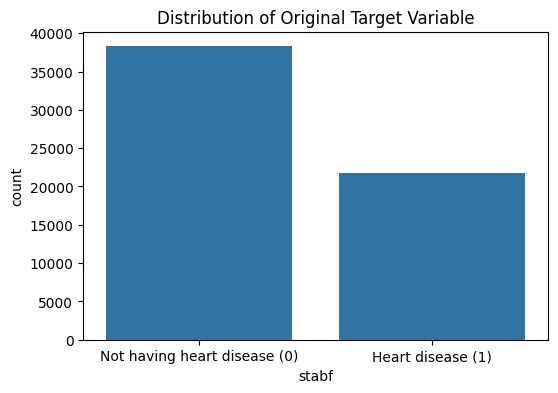

In [12]:
# === Cell 2: Load and Explore Dataset ===

# 1. โหลดข้อมูลจากไฟล์ CSV

df = pd.read_csv('smart_grid_stability_augmented.csv')
print("Dataset 'smart_grid_stability_augmented.csv' loaded successfully!")

# 2. สำรวจข้อมูลเบื้องต้น
print("\n--- 5 แถวแรกของข้อมูล ---")
print(df.head())
print("\n" + "="*50 + "\n")

print("--- ข้อมูลทั่วไปของ DataFrame ---")
df.info()
print("\n" + "="*50 + "\n")

print("--- ตรวจสอบข้อมูลที่หายไป (Missing Values) ---")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

print("--- ค่าสถิติเบื้องต้น ---")
print(df.describe())
print("\n" + "="*50 + "\n")

# 3. แสดงการกระจายของข้อมูลเป้าหมาย
print("--- การกระจายของ Target ('0:Not having heart disease, 1:Heart disease') ---")
plt.figure(figsize=(6, 4))
sns.countplot(x='stabf', data=df)
plt.title('Distribution of Original Target Variable')
plt.xticks([0, 1], ['Not having heart disease (0)', 'Heart disease (1)'])
plt.show()

In [13]:
# === Cell 3: Prepare Data and Split into Train/Test Sets ===

# 1. กำหนด Features (X) และ Target (y)
X = df.drop('stabf', axis=1) # เอาทุกคอลัมน์ยกเว้น 'stabf'
y = df['stabf'] # เอาเฉพาะคอลัมน์ 'stabf'

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# 2. แบ่งข้อมูลเป็นชุด Training (80%) และ Testing (20%)
# random_state=42 เพื่อให้ผลการแบ่งข้อมูลเหมือนเดิมทุกครั้งที่รัน
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- ขนาดของข้อมูลหลังการแบ่ง ---")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Shape of X: (60000, 13)
Shape of y: (60000,)

--- ขนาดของข้อมูลหลังการแบ่ง ---
X_train shape: (48000, 13)
X_test shape: (12000, 13)
y_train shape: (48000,)
y_test shape: (12000,)


In [14]:
# === Cell 4: Feature Scaling ===

# 1. สร้าง object ของ StandardScaler
scaler = StandardScaler()

# 2. ทำการ fit_transform กับข้อมูล X_train (เรียนรู้และแปลงค่า)
X_train_scaled = scaler.fit_transform(X_train)

# 3. ทำการ transform กับข้อมูล X_test (ใช้ค่าที่เรียนรู้จาก train มาแปลง)
X_test_scaled = scaler.transform(X_test)

# แสดงตัวอย่างข้อมูลที่ถูก scale แล้ว
print("--- ตัวอย่างข้อมูล X_train ก่อนทำ Scaling ---")
print(X_train.head(1))
print("\n--- ตัวอย่างข้อมูล X_train หลังทำ Scaling ---")
print(X_train_scaled[0])

--- ตัวอย่างข้อมูล X_train ก่อนทำ Scaling ---
           tau1     tau2      tau3      tau4        p1        p2       p3  \
52739  0.559362  1.29285  9.098544  2.422866  2.987894 -0.971842 -1.20904   

             p4        g1        g2        g3       g4      stab  
52739 -0.807013  0.280071  0.674671  0.456508  0.19949 -0.026138  

--- ตัวอย่างข้อมูล X_train หลังทำ Scaling ---
[-1.70728439 -1.44317975  1.40664176 -1.03055641 -1.00791492  0.64005723
  0.09149529  1.01901872 -0.88980897  0.54325037 -0.25075516 -1.18634536
 -1.13374776]


In [15]:
# === Cell 5: Train the Logistic Regression Model ===

# 1. สร้าง instance ของโมเดล
model = LogisticRegression(random_state=42)

# 2. ฝึกโมเดลด้วยข้อมูล training ที่ scale แล้ว
print("Training the model...")
model.fit(X_train_scaled, y_train)
print("Model training completed!")

Training the model...
Model training completed!


Accuracy: 99.93%


--- Confusion Matrix ---
[[4338    6]
 [   2 7654]]


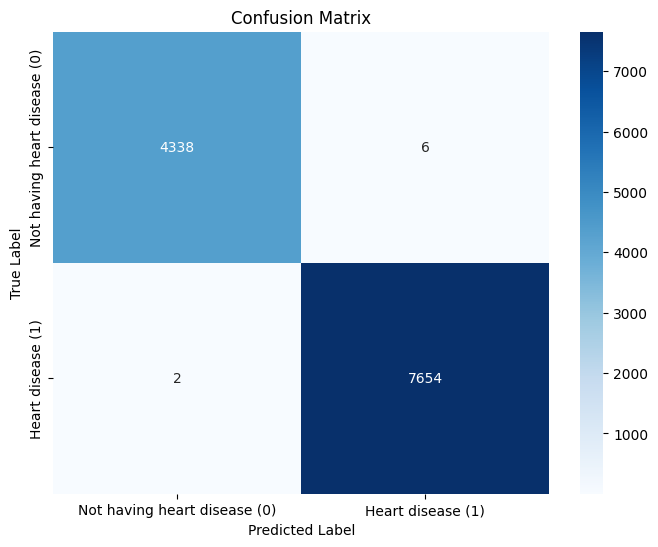



--- Classification Report ---
                              precision    recall  f1-score   support

Not having heart disease (0)       1.00      1.00      1.00      4344
           Heart disease (1)       1.00      1.00      1.00      7656

                    accuracy                           1.00     12000
                   macro avg       1.00      1.00      1.00     12000
                weighted avg       1.00      1.00      1.00     12000



In [16]:
# === Cell 6: Make Predictions and Evaluate the Model ===

# 1. ทำนายผลจากข้อมูล test set
y_pred = model.predict(X_test_scaled)

# 2. วัดผลด้วย Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\n" + "="*50 + "\n")

# 3. สร้างและแสดง Confusion Matrix
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# วาดกราฟ Confusion Matrix เพื่อให้ดูง่ายขึ้น
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not having heart disease (0)', 'Heart disease (1)'], 
            yticklabels=['Not having heart disease (0)', 'Heart disease (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
print("\n" + "="*50 + "\n")

# 4. แสดง Classification Report
print("--- Classification Report ---")
report = classification_report(y_test, y_pred, target_names=['Not having heart disease (0)', 'Heart disease (1)'])
print(report)

In [17]:
# 1. สร้าง instance ของโมเดลด้วยค่า default
baseline_model = LogisticRegression(random_state=42)

# 2. ฝึกโมเดลด้วยข้อมูล training ที่ scale แล้ว
print("Training the baseline model...")
baseline_model.fit(X_train_scaled, y_train)
print("Baseline model training completed!")

# 3. ประเมินผลโมเดลพื้นฐาน
print("\n--- Baseline Model Evaluation ---")
y_pred_baseline = baseline_model.predict(X_test_scaled)
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Model Accuracy: {accuracy_baseline * 100:.2f}%")
print("\nClassification Report for Baseline Model:")
print(classification_report(y_test, y_pred_baseline, target_names=['Not having heart disease (0)', 'Heart disease (1)']))

Training the baseline model...
Baseline model training completed!

--- Baseline Model Evaluation ---
Baseline Model Accuracy: 99.93%

Classification Report for Baseline Model:
                              precision    recall  f1-score   support

Not having heart disease (0)       1.00      1.00      1.00      4344
           Heart disease (1)       1.00      1.00      1.00      7656

                    accuracy                           1.00     12000
                   macro avg       1.00      1.00      1.00     12000
                weighted avg       1.00      1.00      1.00     12000



In [18]:
# === Cell 6: Hyperparameter Tuning with GridSearchCV ===

from sklearn.model_selection import GridSearchCV

# 1. กำหนด Hyperparameter ที่จะทดลอง (Parameter Grid)
# C: ค่า Regularization strength (ค่าน้อย -> Regularization แข็งแกร่ง)
# solver: อัลกอริทึมที่ใช้ในการ optimize
# penalty: ประเภทของ Regularization (l1 หรือ l2)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'], # 'saga' รองรับทั้ง l1 และ l2
    'penalty': ['l1', 'l2', 'elasticnet']
}

# 2. สร้าง instance ของ GridSearchCV
# estimator: โมเดลที่เราต้องการจะจูน
# param_grid: ค่าพารามิเตอร์ที่ต้องการทดลอง
# cv=5: ใช้ 5-fold cross-validation
# scoring='accuracy': เกณฑ์ที่ใช้วัดผลเพื่อหาโมเดลที่ดีที่สุด
# n_jobs=-1: ใช้ CPU ทุก core เพื่อให้ทำงานเร็วขึ้น
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000), # เพิ่ม max_iter ป้องกัน warning
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1 # แสดง log การทำงาน
)

# 3. เริ่มกระบวนการค้นหา Hyperparameter ที่ดีที่สุดบนข้อมูล train
print("Starting GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)
print("GridSearchCV completed!")

# 4. แสดงผล Hyperparameter ที่ดีที่สุดที่ค้นพบ
print("\n--- Best Hyperparameters Found ---")
print(grid_search.best_params_)

# 5. แสดง score ที่ดีที่สุดที่ได้จาก Cross-validation
print(f"\nBest Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

Starting GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
300 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/li

GridSearchCV completed!

--- Best Hyperparameters Found ---
{'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}

Best Cross-Validation Accuracy: 99.97%



--- Best Model Evaluation on Test Set ---
Tuned Model Accuracy: 99.97%
Baseline Model Accuracy: 99.93%


--- Confusion Matrix for Tuned Model ---


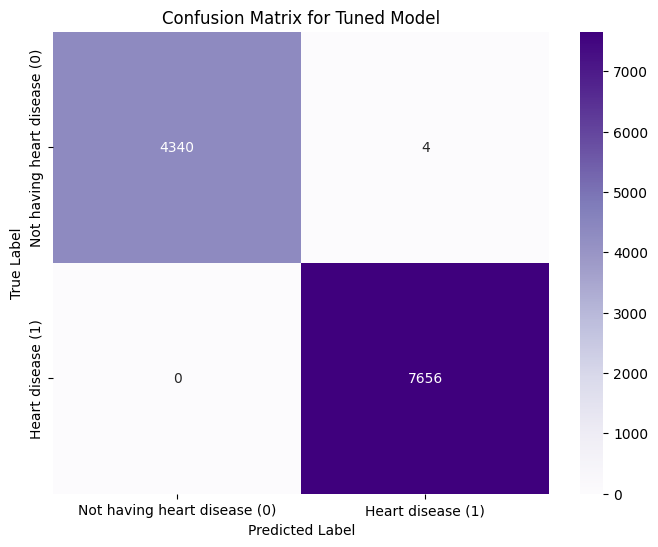



--- Classification Report for Tuned Model ---
                              precision    recall  f1-score   support

Not having heart disease (0)       1.00      1.00      1.00      4344
           Heart disease (1)       1.00      1.00      1.00      7656

                    accuracy                           1.00     12000
                   macro avg       1.00      1.00      1.00     12000
                weighted avg       1.00      1.00      1.00     12000



In [19]:
# === Cell 7: Evaluate the Best Model Found by GridSearchCV ===

# 1. ดึงโมเดลที่ดีที่สุดออกมา
best_model = grid_search.best_estimator_

# 2. ทำนายผลจากข้อมูล test set ด้วยโมเดลที่ดีที่สุด
y_pred_best = best_model.predict(X_test_scaled)

# 3. ประเมินผลโมเดลที่ดีที่สุด
print("\n--- Best Model Evaluation on Test Set ---")
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Tuned Model Accuracy: {accuracy_best * 100:.2f}%")
print(f"Baseline Model Accuracy: {accuracy_baseline * 100:.2f}%") # เทียบกับ baseline
print("\n" + "="*50 + "\n")


# 4. แสดง Confusion Matrix ของโมเดลที่ดีที่สุด
print("--- Confusion Matrix for Tuned Model ---")
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Not having heart disease (0)', 'Heart disease (1)'], 
            yticklabels=['Not having heart disease (0)', 'Heart disease (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned Model')
plt.show()
print("\n" + "="*50 + "\n")


# 5. แสดง Classification Report ของโมเดลที่ดีที่สุด
print("--- Classification Report for Tuned Model ---")
print(classification_report(y_test, y_pred_best, target_names=['Not having heart disease (0)', 'Heart disease (1)']))